# Student Performance Prediction Dataset
**Algoritma:** Linear Regression

## Overview

Dataset ini berisi informasi mengenai kebiasaan belajar dan faktor-faktor yang memengaruhi performa akademik siswa. Setiap data merepresentasikan seorang siswa dengan berbagai karakteristik, seperti durasi belajar, nilai sebelumnya, aktivitas ekstrakurikuler, jam tidur, serta jumlah latihan soal yang telah dikerjakan. Dataset ini dapat digunakan untuk menganalisis hubungan antara kebiasaan belajar dan pencapaian akademik, sekaligus membangun model prediksi performa siswa.

## Objective

Tujuan utama analisis adalah membangun model machine learning yang mampu memprediksi **Performance Index (`Performance Index`)** berdasarkan kebiasaan belajar, riwayat nilai, aktivitas ekstrakurikuler, kualitas istirahat, dan intensitas latihan soal.

## Features

| Feature | Description |
|---------|-------------|
| `Hours Studied` | Total jam belajar yang dihabiskan oleh siswa. |
| `Previous Scores` | Nilai yang diperoleh siswa pada ujian atau evaluasi sebelumnya. |
| `Extracurricular Activities` | Status keikutsertaan siswa dalam kegiatan ekstrakurikuler (`Yes` atau `No`). |
| `Sleep Hours` | Rata-rata jumlah jam tidur siswa setiap hari. |
| `Sample Question Papers Practiced` | Jumlah soal atau latihan ujian yang telah dikerjakan siswa sebagai persiapan belajar. |
| `Performance Index` | Indeks performa akademik siswa dengan rentang nilai **10–100** (**target/label**). Nilai yang lebih tinggi menunjukkan performa akademik yang lebih baik. |

## Download Dataset

### Import Library

In [157]:
import os
import kagglehub
import shutil

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

### Download

In [159]:
path = kagglehub.dataset_download("nikhil7280/student-performance-multiple-linear-regression")

shutil.copytree(path, './datasets/')

'./datasets/'

In [ ]:
filename = os.listdir('./datasets/')
print(os.join)

['Student_Performance.csv']


## Load Dataset

In [160]:
# buat dataframe
df = pd.read_csv('./datasets/Student_Performance.csv')
df.sample(3) # ambil 3 sampel acak

,Hours Studied,Previous Scores,Extracurricular Activities,Sleep Hours,Sample Question Papers Practiced,Performance Index
7904,4,58,Yes,7,2,46.0
7678,2,69,No,8,8,49.0
6296,9,72,No,9,8,69.0


## Exploratory Data Analysis

### deskripsi data

In [161]:
df.describe()

,Hours Studied,Previous Scores,Sleep Hours,Sample Question Papers Practiced,Performance Index
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,4.992900,69.445700,6.530600,4.583300,55.224800
std,2.589309,17.343152,1.695863,2.867348,19.212558
min,1.000000,40.000000,4.000000,0.000000,10.000000
25%,3.000000,54.000000,5.000000,2.000000,40.000000
50%,5.000000,69.000000,7.000000,5.000000,55.000000
75%,7.000000,85.000000,8.000000,7.000000,71.000000
max,9.000000,99.000000,9.000000,9.000000,100.000000


### informasi data

In [162]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 6 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   Hours Studied                     10000 non-null  int64  
 1   Previous Scores                   10000 non-null  int64  
 2   Extracurricular Activities        10000 non-null  str    
 3   Sleep Hours                       10000 non-null  int64  
 4   Sample Question Papers Practiced  10000 non-null  int64  
 5   Performance Index                 10000 non-null  float64
dtypes: float64(1), int64(4), str(1)
memory usage: 468.9 KB


### cek data kosong

In [163]:
df.isnull().sum()

Hours Studied                       0
Previous Scores                     0
Extracurricular Activities          0
Sleep Hours                         0
Sample Question Papers Practiced    0
Performance Index                   0
dtype: int64

## Exploratory Data Analysis

### Ubah `Extracurricular Activities` menjadi biner

In [164]:
df['Extracurricular Activities'] = df['Extracurricular Activities'].map({'Yes': 1, 'No': 0})
df.sample(3)

,Hours Studied,Previous Scores,Extracurricular Activities,Sleep Hours,Sample Question Papers Practiced,Performance Index
7110,3,98,0,5,9,76.0
333,8,45,1,6,2,38.0
2996,3,88,0,9,1,67.0


### Melihat distribusi data

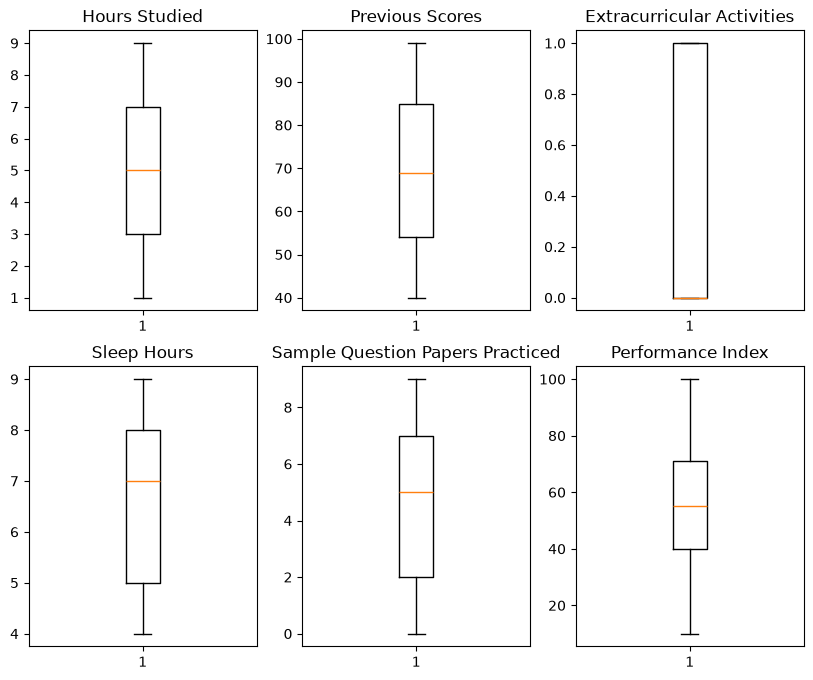

In [166]:
cols = [
    'Hours Studied', 
    'Previous Scores',
    'Extracurricular Activities', 
    'Sleep Hours', 
    'Sample Question Papers Practiced', 
    'Performance Index'
    ]

fig, axis = plt.subplots(ncols=3, nrows=2, figsize=(10, 8))
axis = axis.flatten()

for i, col in enumerate(cols):
    axis[i].boxplot(df[col])
    axis[i].set_title(col)
plt.show()

### Penjelasan Boxplot

* **Hours Studied**: Variabel *Hours Studied* memiliki rentang nilai antara 1 hingga 9 jam. Median berada pada 5 jam, yang menunjukkan bahwa sebagian besar siswa menghabiskan waktu belajar sekitar 5 jam. Selain itu, mayoritas data berada pada kisaran 3 hingga 7 jam.

* **Previous Scores**: Variabel *Previous Scores* memiliki rentang nilai antara 40 hingga 100, dengan median sebesar 70. Sebagian besar siswa memperoleh nilai pada kisaran 55 hingga 85.

* **Extracurricular Activities**: Distribusi data menunjukkan bahwa jumlah siswa yang tidak mengikuti kegiatan ekstrakurikuler lebih banyak dibandingkan siswa yang mengikuti kegiatan ekstrakurikuler.

* **Sleep Hours**: Variabel *Sleep Hours* memiliki rentang antara 4 hingga 9 jam. Median berada pada 7 jam, sedangkan mayoritas siswa memiliki durasi tidur pada kisaran 5 hingga 8 jam.

* **Sample Question Papers Practiced**: Variabel *Sample Question Papers Practiced* memiliki rentang antara 1 hingga 9 soal. Median berada pada 5 soal, dan sebagian besar siswa mengerjakan antara 2 hingga 7 contoh soal.

* **Performance Index**: Variabel *Performance Index* memiliki rentang nilai antara 10 hingga 100. Median berada pada nilai 59, sementara mayoritas siswa memperoleh nilai performa pada kisaran 40 hingga 70.


### Melihat hubungan data terhadap Performance Index

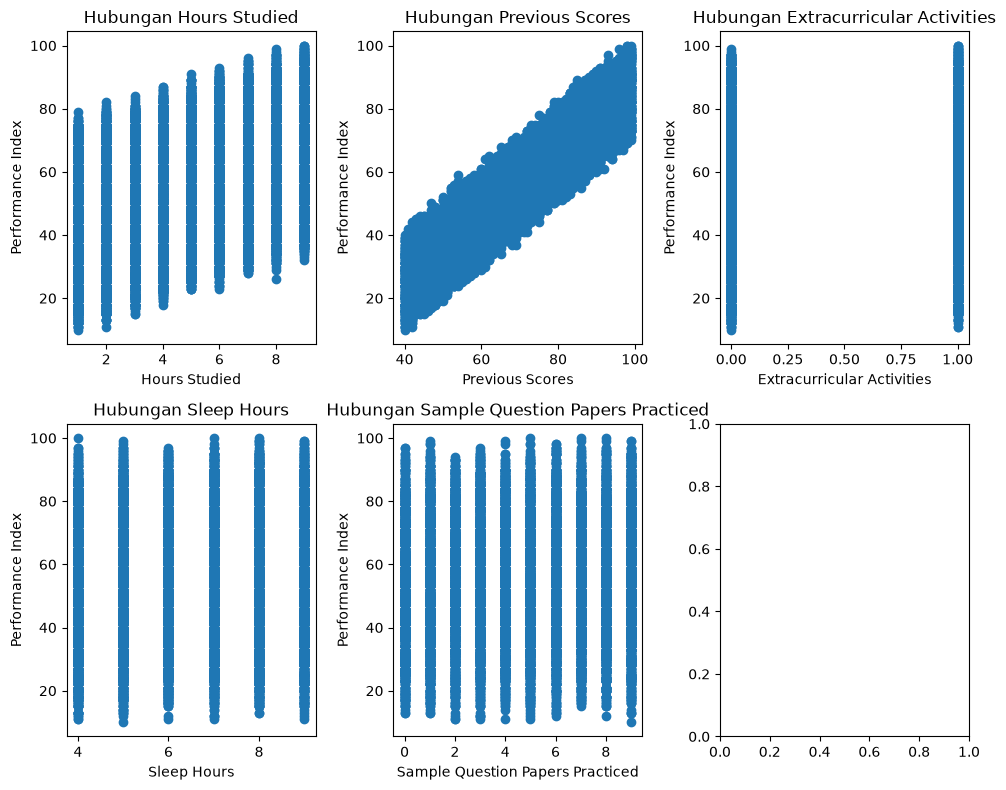

In [170]:
cols = [
    'Hours Studied', 
    'Previous Scores',
    'Extracurricular Activities', 
    'Sleep Hours', 
    'Sample Question Papers Practiced'
    ]

fig, axis = plt.subplots(ncols=3, nrows=2, figsize=(10, 8))
axis = axis.flatten()

for i, col in enumerate(cols):
    axis[i].scatter(df[col], df['Performance Index'])
    axis[i].set_xlabel(col)
    axis[i].set_ylabel("Performance Index")
    axis[i].set_title(f"Hubungan {col}")
    plt.tight_layout()
plt.show()

### Penjelasan:
- **Hours Studied**: Semakin lama belajar, maka semakin tinggi juga performanya.
- **Previous Score**: Nilai ujian sebelumnya sangat berpengaruh terhadap kenaikan performa.
- **Extracurricular, Sleep Hours, dan Sample Question Papers Practiced**: tidak terlalu berpengaruh terhapad performa.

### Melihat Korelasi data

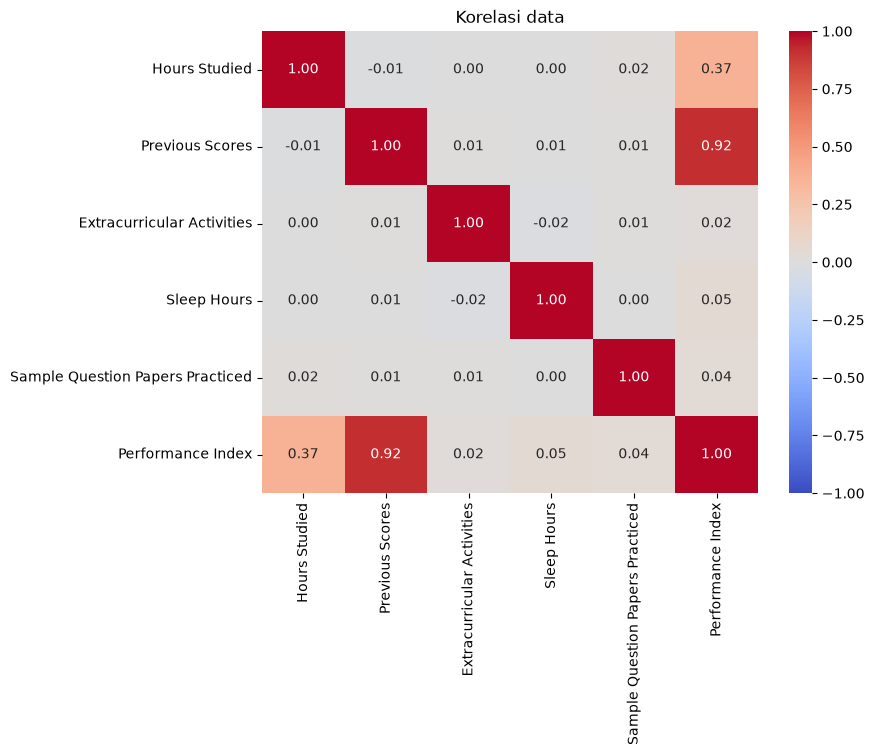

In [171]:
corr = df.corr()
plt.figure(figsize=(8, 6))
sns.heatmap(corr, fmt=".2f", annot=True, cmap="coolwarm", vmin=-1, vmax=1)
plt.title("Korelasi data")
plt.show()

### Penjelasan:
`Hours Studied (0.37)`,`Previous Scores(0.92)` sangat berkorelasi terhadap `Performance Index`, jika keduanya naik maka performanya juga akan semakin bagus.

## Feature Engineering

### Menambahkan fitur baru dari fitur yang sudah ada

In [177]:
# mengalikan hours studied dengan previous score
df['study_score_interaction'] = df['Hours Studied'] * df['Previous Scores']
# Ditambah 0.1 di pembagi agar tidak terjadi error pembagian dengan angka nol
df['sleep_to_study_ratio'] = df['Sleep Hours'] / (df['Hours Studied'] + 0.1)
df['hours_studied_squared'] = df['Hours Studied'] ** 2


cols = [
    'Hours Studied',
    'Previous Scores',
    'Extracurricular Activities',
    'Sleep Hours',
    'Sample Question Papers Practiced',
    'study_score_interaction',
    'sleep_to_study_ratio',
    'hours_studied_squared',  
    'Performance Index'
]

df = df[cols].sort_values(by='Performance Index')

df.sample()

,Hours Studied,Previous Scores,Extracurricular Activities,Sleep Hours,Sample Question Papers Practiced,study_score_interaction,sleep_to_study_ratio,hours_studied_squared,Performance Index
4746,1,68,0,4,1,68,3.636364,1,38.0


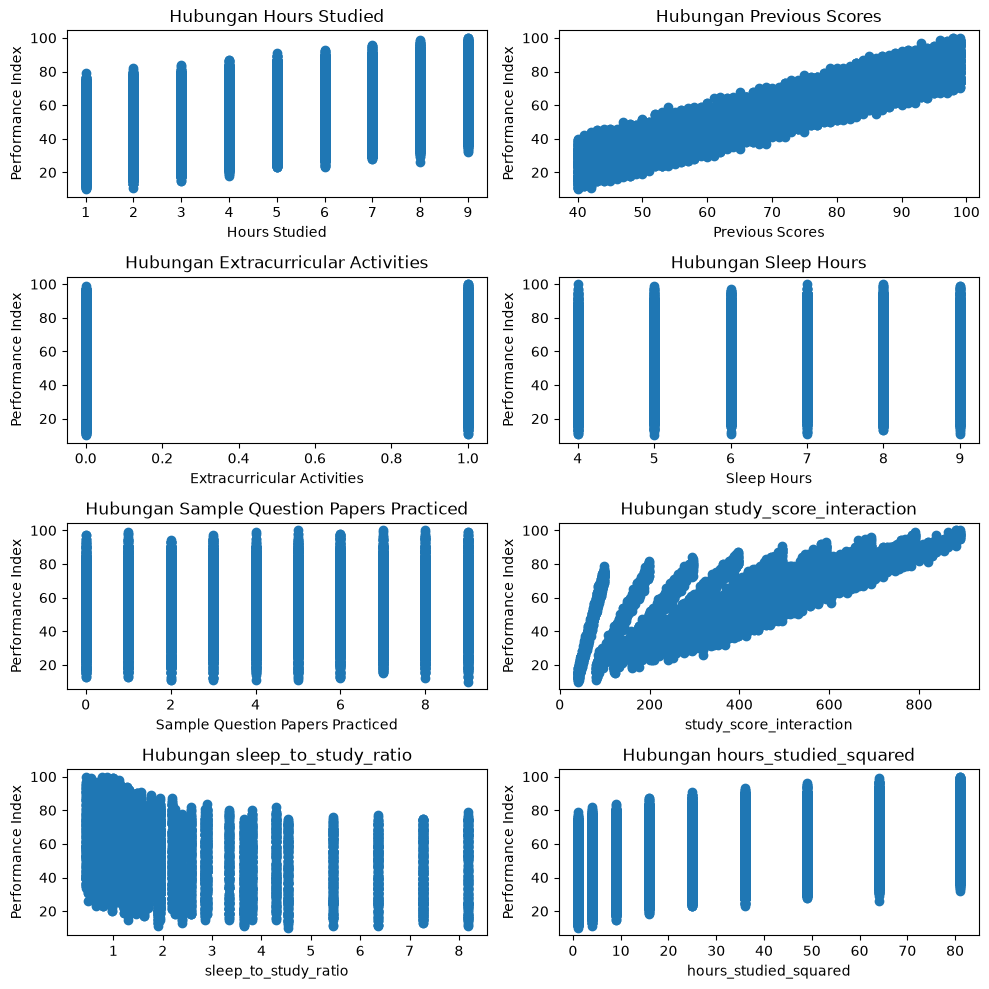

In [175]:
cols = [
    'Hours Studied',
    'Previous Scores',
    'Extracurricular Activities',
    'Sleep Hours',
    'Sample Question Papers Practiced',
    'study_score_interaction',
    'sleep_to_study_ratio',
    'hours_studied_squared'
    ]

fig, axis = plt.subplots(ncols=2, nrows=4, figsize=(10, 10))
axis = axis.flatten()

for i, col in enumerate(cols):
    axis[i].scatter(df[col], df['Performance Index'])
    axis[i].set_xlabel(col)
    axis[i].set_ylabel("Performance Index")
    axis[i].set_title(f"Hubungan {col}")
    plt.tight_layout()
plt.show()

### Penjelasan:
- **Hours Studied**: Semakin lama belajar, maka semakin tinggi juga performanya.
- **Previous Score**: Nilai ujian sebelumnya sangat berpengaruh terhadap kenaikan performa.
- **Extracurricular, Sleep Hours, dan Sample Question Papers Practiced**: tidak terlalu berpengaruh terhapad performa.
- **Study Score Interaction**: Kombinasi waktu belajar dan nilai ujian sebelumnya sangat berpengaruh terhadap performa.
- **Sleep to Study ratio**: Menunjukan grafik yang semakin turun, semakin banyak tidur, otomatis waktu belajar juga berkurang, dan ini membuat performa menurun.

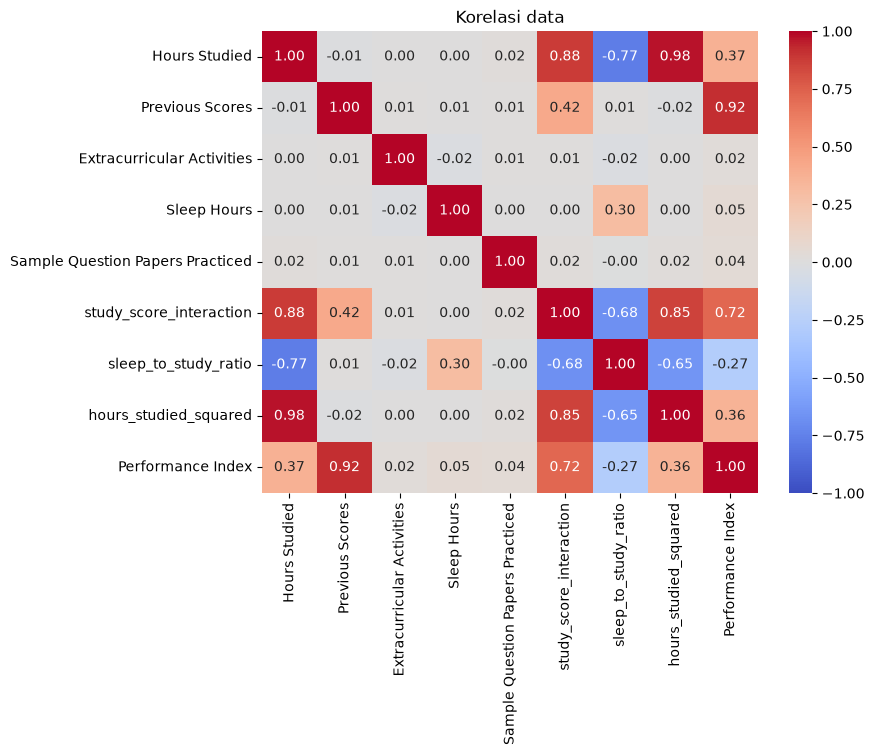

In [176]:
corr = df.corr()
plt.figure(figsize=(8, 6))
sns.heatmap(corr, fmt=".2f", annot=True, cmap="coolwarm", vmin=-1, vmax=1)
plt.title("Korelasi data")
plt.show()

### Penjelasan:
`Hours Studied (0.37)`,`Previous Scores(0.92)` sangat berkorelasi terhadap `Performance Index`, jika keduanya naik maka performanya juga akan semakin bagus. `Study Score Interaction(0.72)` juga memiliki pengaruh besar terhadap performa.

**Fitur yang akan di ambil**:

Saya akan mengambil `Previous scores`, `study score interaction`, `hours studied`, dan `sleep to study ratio`.

## Split Dataset

In [178]:
X = df[['Previous Scores', 'study_score_interaction', 'Hours Studied', 'sleep_to_study_ratio']]
y = df['Performance Index']
X.shape

(10000, 4)

In [179]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    random_state=42,
    test_size=0.3, # 30% data test, dan 70% data training
)

## Model Baseline

In [180]:
model = LinearRegression()

## Training model

In [181]:
model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](4,)","[1.02,0. ,3.01,0.37]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](4,)","['Previous Scores','study_score_interaction','Hours Studied', 'sleep_to_study_ratio']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,-31.36
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,4
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(4)


## Evaluasi

In [185]:
y_train_pred = model.predict(X_train)
y_test_pred = model.predict(X_test)

In [187]:
mse_train = mean_squared_error(y_train_pred, y_train)
mae_train = mean_absolute_error(y_train_pred, y_train)
r2_train = r2_score(y_train_pred, y_train)

mse_test = mean_squared_error(y_test_pred, y_test)
mae_test = mean_absolute_error(y_test_pred, y_test)
r2_test = r2_score(y_test_pred, y_test)

print(f"Mean Squared Error test: {mse_test:.2f}")
print(f"Mean Absolute Error test: {mae_test:.2f}")
print(f"R2 score test: {r2_test:.0%}")

print(f"Mean Squared Error train: {mse_train:.2f}")
print(f"Mean Absolute Error train: {mae_train:.2f}")
print(f"R2 score train: {r2_train:.0%}")



Mean Squared Error test: 5.13
Mean Absolute Error test: 1.80
R2 score test: 99%
Mean Squared Error train: 5.02
Mean Absolute Error train: 1.78
R2 score train: 99%


### Penjelasan Evaluasi:

Berdasarkan hasil evaluasi model, performa regresi yang dihasilkan sangat memuaskan dengan kemampuan prediksi yang sangat tinggi. Model berhasil mencapai **R2 Score sebesar 0.99 (99%) baik pada data training maupun data testing**. Hal ini mengindikasikan bahwa 99% variasi faktor yang memengaruhi Performance Index siswa telah berhasil dipelajari dengan sempurna oleh model.Tingkat kesalahan prediksi juga tergolong sangat rendah dan konsisten pada kedua kelompok data. Pada data pengujian (testing), model mencatatkan nilai **MAE sebesar 1.80** dan **MSE sebesar 5.13**, yang tidak berbeda jauh dari nilai error pada data training. Kesamaan performa yang seimbang antara data training dan data testing ini menjadi **bukti kuat bahwa model tidak mengalami overfitting**. Pemilihan fitur (feature selection) yang dilakukan sebelumnya terbukti berhasil membuat model memiliki kemampuan generalisasi yang sangat baik, stabil, dan siap digunakan untuk memprediksi data baru.